# Kaggle PlayGround 2026年2月実施分　おまけ


## Predict strikeouts with new MLB arm angle data

[https://www.kaggle.com/competitions/nwds-k/data](https://www.kaggle.com/competitions/nwds-k/data)

### おまけ

In [2]:
!pip install -q japanize-matplotlib
import japanize_matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, accuracy_score, log_loss, precision_score, recall_score, f1_score
from lightgbm import early_stopping, log_evaluation
import shap
from scipy import stats
import matplotlib.font_manager as fm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 42.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


軌道を見たい球の行番号を入力してください (0 〜 666511): 1
=== 1行目のデータを読み込みました ===
球種: 4-Seam Fastball
球速: 96.1 mph
回転: 2452.0rpm
結果: 0　※1 = ストライク


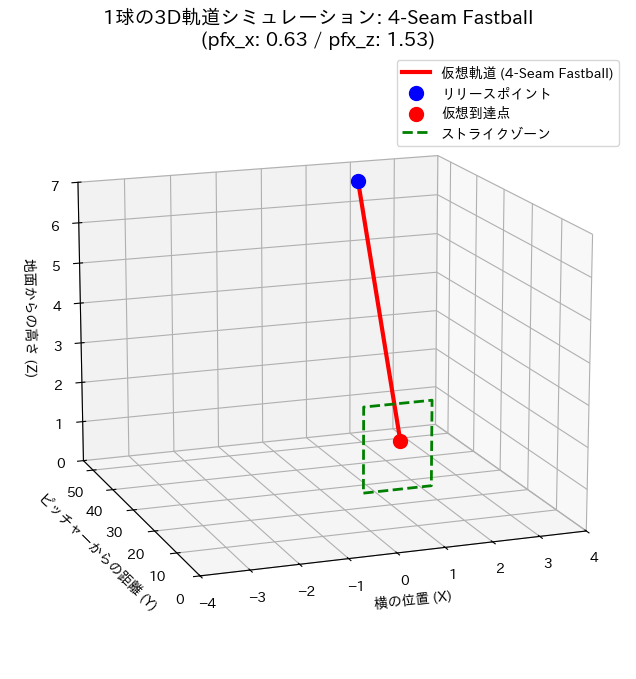

In [3]:
from mpl_toolkits.mplot3d import Axes3D

# ここは読み込んだ元のデータフレーム名（dfなど）を指定してください
df_sim = pd.read_csv('train.csv')
max_idx = len(df_sim) - 1

try:
    user_input = input(f"軌道を見たい球の行番号を入力してください (0 〜 {max_idx}): ")
    target_idx = int(user_input)

    sample_pitch = df_sim.iloc[target_idx]

    print(f"=== {target_idx}行目のデータを読み込みました ===")
    print(f"球種: {sample_pitch['pitch_name']}")
    print(f"球速: {sample_pitch['release_speed']} mph")
    print(f"回転: {sample_pitch['release_spin_rate']}rpm")
    print(f"結果: {sample_pitch['is_strike']}　※1 = ストライク")

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    release_y = 50.0
    plate_y = 0.0

    # スタート地点（リリースポイント）
    x0 = sample_pitch['release_pos_x']
    z0 = sample_pitch['release_pos_z']

    # 【マジック！】到達点がないなら、変化量(pfx)から逆算してシミュレーションする
    # ※ pfx は「インチ」なので、12で割って「フィート」に変換します
    # ※ ど真ん中（X=0, Z=2.5）に向かって投げた球が、pfx分だけズレたと仮定
    sim_plate_x = 0.0 + (sample_pitch['pfx_x'] / 12.0)
    sim_plate_z = 2.5 + (sample_pitch['pfx_z'] / 12.0)

    y_vals = np.linspace(release_y, plate_y, 100)
    x_vals = np.linspace(x0, sim_plate_x, 100)
    z_vals = np.linspace(z0, sim_plate_z, 100)

    ax.plot(x_vals, y_vals, z_vals, color='red', linewidth=3, label=f"仮想軌道 ({sample_pitch['pitch_name']})")
    ax.scatter(x0, release_y, z0, color='blue', s=100, label='リリースポイント')
    ax.scatter(sim_plate_x, plate_y, sim_plate_z, color='red', s=100, label='仮想到達点')

    # ストライクゾーンの枠
    sz_top, sz_bot, sz_left, sz_right = 3.5, 1.5, -0.7, 0.7
    zone_x = [sz_left, sz_right, sz_right, sz_left, sz_left]
    zone_z = [sz_bot, sz_bot, sz_top, sz_top, sz_bot]
    zone_y = [0, 0, 0, 0, 0]
    ax.plot(zone_x, zone_y, zone_z, color='green', linewidth=2, linestyle='--', label='ストライクゾーン')

    ax.set_title(f"1球の3D軌道シミュレーション: {sample_pitch['pitch_name']}\n(pfx_x: {sample_pitch['pfx_x']} / pfx_z: {sample_pitch['pfx_z']})", fontsize=14)
    ax.set_xlabel('横の位置 (X)')
    ax.set_ylabel('ピッチャーからの距離 (Y)')
    ax.set_zlabel('地面からの高さ (Z)')

    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 55)
    ax.set_zlim(0, 7)
    ax.view_init(elev=15, azim=-110)

    plt.legend()
    plt.show()

except ValueError:
    print("エラー: 半角の数字だけを入力してください！")
except IndexError:
    print(f"エラー: {max_idx} を超える行番号は存在しません！")